# Earth Observation Data and Tools for Climate Resilience and Risk Monitoring
## with medium-resolution EO examples for Africa and Asia

This notebook is focused on:
- medium-resolution Earth Observation (EO) datasets such as **Sentinel-3**, **MODIS**, and a few complementary products;
- practical access patterns using **STAC API**, **Microsoft Planetary Computer (MPC)**, **Google Earth Engine (GEE)**, **Xee**, and **cubo**;
- simple climate resilience and risk-monitoring examples for **Africa** and **Asia**.

### Tutorial structure
1. Why medium-resolution EO for resilience and risk monitoring
2. Data access options: STAC, MPC, GEE, Xee, cubo
3. Example A (Africa): vegetation and drought context with MODIS NDVI
4. Example B (Asia): coastal and delta monitoring with Sentinel-3 OLCI
5. Integrated approach: combine EO with climate context
6. Wrap-up, limitations, and next steps

> This notebook is built as a **teaching notebook**. Some cells may require authentication or internet access and are meant for live demonstration rather than offline execution.

## Learning objectives

By the end of the session, participants should be able to:
- explain why medium-resolution EO is useful for continental and regional monitoring;
- discover datasets with a **STAC API**;
- read EO data from **Microsoft Planetary Computer**;
- access Earth Engine collections in Python with **GEE** and **Xee**;
- use **cubo** as a higher-level data-cube interface for both STAC and GEE;
- build basic resilience indicators such as:
  - NDVI time series,
  - simple anomalies,
  - rainfall + vegetation context,
  - coastal water/land color quicklooks.

## Why medium-resolution EO?

Medium-resolution EO is often a strong fit for climate resilience because it balances:
- **spatial detail** sufficient for regional landscapes, coastlines, croplands, and large water bodies;
- **temporal frequency** suitable for anomaly detection and seasonal monitoring;
- **manageable data volume** for teaching and prototyping.

### Typical use cases
- drought and vegetation stress,
- flood extent context,
- water quality and coastal monitoring,
- land surface conditions,
- seasonal food-security and livelihood monitoring.

## Datasets used in this tutorial

### Core datasets
- **MODIS MOD13Q1 / MYD13Q1**: 16-day vegetation indices at **250 m**
- **Sentinel-3 OLCI**: ocean and land color radiances at **300 m**
- optional complementary context:
  - **CHIRPS** rainfall,
  - **MODIS LST**,
  - **Sentinel-3 SLSTR** where relevant

### Study areas
- **Africa**: Somali Region of Ethiopia / East Africa vegetation monitoring (##Todo - Reference)
- **Asia**: Ganges-Brahmaputra delta or Mekong delta coastal-water example

You can replace these AOIs with your own polygons later.

In [ ]:
#!python -m pip install -q cubo xarray dask[complete] pystac-client planetary-computer xee earthengine-api geemap matplotlib pandas numpy shapely geopandas contextily
#
# Optional depending on your workflow:
#!python -m pip install -q odc-stac stackstac rioxarray

In [8]:
!python -m pip freeze > requirements.txt

## Imports

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx

from shapely.geometry import box, mapping

# STAC / MPC
from pystac_client import Client
import planetary_computer as pc

# GEE / Xee
import ee
import xee

# Cubo
import cubo

## Authentication notes

### Earth Engine
For local Jupyter:
```python
ee.Authenticate()
ee.Initialize(project="YOUR_GEE_PROJECT")
```

For high-volume endpoint when appropriate:
```python
ee.Initialize(project="YOUR_GEE_PROJECT",
              opt_url="https://earthengine-highvolume.googleapis.com")
```

### Microsoft Planetary Computer
The STAC API is public for metadata search. Asset access often requires **signing** with `planetary_computer.sign_inplace(...)` or a modifier function in `pystac-client`.

In [4]:

# Uncomment when running locally for the first time:
ee.Authenticate()

# Example initialization:
ee.Initialize(project="ee-kizarzakir")

# Or high-volume endpoint:
# ee.Initialize(
#     project="YOUR_GEE_PROJECT",
#     opt_url="https://earthengine-highvolume.googleapis.com"
# )


Successfully saved authorization token.


## Helper variables: Africa and Asia AOIs

In [23]:

# Africa example: 
africa_bbox = [43.503799,5.721212,43.839569,5.952095]   # minx, miny, maxx, maxy 


# Asia example: Ganges-Brahmaputra delta / coastal Bangladesh (broad bbox)
asia_bbox = [88.231201,21.399377,89.288635,22.629223]

africa_geom = mapping(box(*africa_bbox))
asia_geom = mapping(box(*asia_bbox))

print("Africa bbox:", africa_bbox)
print("Asia bbox:", asia_bbox)

Africa bbox: [43.503799, 5.721212, 43.839569, 5.952095]
Asia bbox: [88.231201, 21.399377, 89.288635, 22.629223]


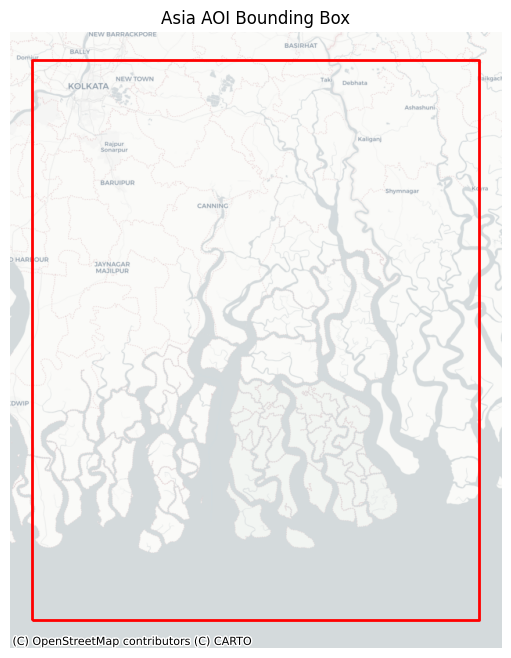

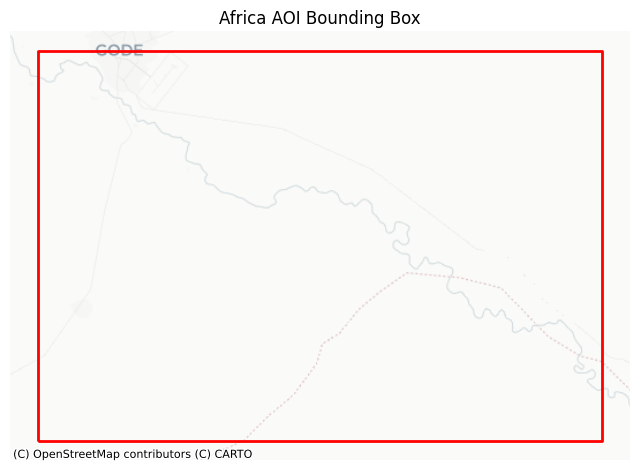

In [25]:
# Visualize Asia bbox using GeoPandas + simple basemap
bbox_gdf = gpd.GeoDataFrame(
    {"name": ["Asia AOI"]},
    geometry=[box(*asia_bbox)],
    crs="EPSG:4326",
)

bbox_3857 = bbox_gdf.to_crs(epsg=3857)
ax = bbox_3857.boundary.plot(figsize=(8, 8), color="red", linewidth=2)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title("Asia AOI Bounding Box")
ax.set_axis_off()
plt.show()

bbox_gdf = gpd.GeoDataFrame(
    {"name": ["Africa AOI"]},
    geometry=[box(*africa_bbox)],
    crs="EPSG:4326",
)

bbox_3857 = bbox_gdf.to_crs(epsg=3857)
ax = bbox_3857.boundary.plot(figsize=(8, 8), color="red", linewidth=2)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title("Africa AOI Bounding Box")
ax.set_axis_off()
plt.show()


# Part 1 — Discover data with STAC API and MPC

This section shows the lowest-friction pattern:
1. open a STAC API,
2. search a collection by space and time,
3. inspect returned items,
4. optionally pass those results into higher-level tooling later.

In [32]:

# Microsoft Planetary Computer STAC
stac_url = "https://planetarycomputer.microsoft.com/api/stac/v1"

catalog = Client.open(
    stac_url,
    modifier=pc.sign_inplace,  # automatically sign returned items/assets
)

print(catalog)

<Client id=microsoft-pc>


In [27]:
print ("Collections available in the catalog:")
for collection in catalog.get_collections():
    print("-", collection.id)

Collections available in the catalog:
- daymet-annual-pr
- daymet-daily-hi
- 3dep-seamless
- 3dep-lidar-dsm
- fia
- gridmet
- daymet-annual-na
- daymet-monthly-na
- daymet-annual-hi
- daymet-monthly-hi
- daymet-monthly-pr
- gnatsgo-tables
- hgb
- cop-dem-glo-30
- cop-dem-glo-90
- terraclimate
- nasa-nex-gddp-cmip6
- gpm-imerg-hhr
- gnatsgo-rasters
- 3dep-lidar-hag
- io-lulc-annual-v02
- goes-cmi
- conus404
- sentinel-1-rtc
- noaa-hrrr
- 3dep-lidar-intensity
- 3dep-lidar-pointsourceid
- mtbs
- noaa-c-cap
- 3dep-lidar-copc
- modis-64A1-061
- alos-fnf-mosaic
- 3dep-lidar-returns
- mobi
- landsat-c2-l2
- chloris-biomass
- kaza-hydroforecast
- planet-nicfi-analytic
- modis-17A2H-061
- modis-11A2-061
- daymet-daily-pr
- 3dep-lidar-dtm-native
- 3dep-lidar-classification
- 3dep-lidar-dtm
- gap
- modis-17A2HGF-061
- planet-nicfi-visual
- gbif
- modis-17A3HGF-061
- modis-09A1-061
- alos-dem
- alos-palsar-mosaic
- deltares-water-availability
- modis-16A3GF-061
- modis-21A2-061
- us-census
- jrc-g

In [40]:
# collection tree
modis_collection = catalog.get_collection("modis-13Q1-061")
modis_collection

<CollectionClient id=modis-13Q1-061>

## Example 1A: Search MODIS NDVI for Africa

In [41]:

search_modis_africa = catalog.search(
    collections=["modis-13Q1-061"],
    bbox=africa_bbox,
    datetime="2021-03-01/2022-05-31",
    limit=5,
)

items_modis_africa = list(search_modis_africa.items())
print(f"Returned {len(items_modis_africa)} items")
print("Top 3 items:")
for item in items_modis_africa[:3]:
    print(item.id, item.datetime)

Returned 64 items
Top 3 items:
MOD13Q1.A2022145.h22v08.061.2022168103056 None
MYD13Q1.A2022137.h22v08.061.2022154045415 None
MOD13Q1.A2022129.h22v08.061.2022146012606 None


### Important Note
- STAC separates **collection metadata** from **items/assets**.
- A STAC search is often the most transferable pattern across cloud EO catalogs.
- MPC is a good demonstration platform because it exposes many datasets through a standard STAC API.

## Example 1B: Search Sentinel-3 for Asia

In [42]:

# Depending on the exact teaching goal, you may choose one of several Sentinel-3 collections.
# Here we use a generic Sentinel-3 OLCI-related example available through MPC's STAC.

search_s3_asia = catalog.search(
    collections=["sentinel-3-olci-lfr-l2-netcdf"],
    bbox=asia_bbox,
    datetime="2023-01-01/2023-03-31",
    limit=5,
)

items_s3_asia = list(search_s3_asia.items())
print(f"Returned {len(items_s3_asia)} items")
print("Top 3 items:")
for item in items_s3_asia[:3]:
    print(item.id, item.datetime)

Returned 103 items
Top 3 items:
S3B_OL_2_LFR_20230331T041051_20230331T041351_0179_077_375_2520 2023-03-31 04:12:20.862527+00:00
S3A_OL_2_LFR_20230329T040127_20230329T040427_0179_097_104_2520 2023-03-29 04:02:56.917703+00:00
S3A_OL_2_LFR_20230328T042738_20230328T043038_0180_097_090_2520 2023-03-28 04:29:07.780818+00:00


## Optional: Inspect asset names from a returned STAC item

In [43]:

if items_modis_africa:
    first_item = items_modis_africa[0]
    print("Item ID:", first_item.id)
    print("Assets:")
    for k in first_item.assets:
        print(" -", k)

Item ID: MOD13Q1.A2022145.h22v08.061.2022168103056
Assets:
 - hdf
 - metadata
 - 250m_16_days_EVI
 - 250m_16_days_NDVI
 - 250m_16_days_VI_Quality
 - 250m_16_days_MIR_reflectance
 - 250m_16_days_NIR_reflectance
 - 250m_16_days_red_reflectance
 - 250m_16_days_blue_reflectance
 - 250m_16_days_sun_zenith_angle
 - 250m_16_days_pixel_reliability
 - 250m_16_days_view_zenith_angle
 - 250m_16_days_relative_azimuth_angle
 - 250m_16_days_composite_day_of_the_year
 - tilejson
 - rendered_preview


# Part 2 — Use `cubo` as a simpler data-cube interface

`cubo` is handy because it gives a compact, xarray-friendly entry point and supports **STAC** and **GEE** workflows.

## Example 2A: `cubo` with STAC-like workflow (Africa)

This is a compact pattern for building an on-demand EO mini-cube around a point.

- the cube small,
- the time range short,
- the number of bands minimal.

In [ ]:
# A point near Somali Region of Ethiopia
lat_africa = 5.947659
lon_africa = 43.559889

start_date = "2021-05-01"
end_date = "2022-05-31"

# a simple cube demonstration
da_africa_cubo = cubo.create(
    lat=lat_africa,
    lon=lon_africa,
    collection="modis-13Q1-061",
    bands=["250m_16_days_NDVI"],
    start_date=start_date,
    end_date=end_date,
    edge_size=64,
    resolution=250,
)


da_africa_cubo

<xarray.DataArray 'modis-13Q1-061' (time: 56, band: 1, y: 64, x: 64)> Size: 2MB
dask.array<fetch_raster_window, shape=(56, 1, 64, 64), dtype=float64, chunksize=(1, 1, 64, 64), chunktype=numpy.ndarray>
Coordinates: (12/22)
  * time                       (time) datetime64[ns] 448B NaT NaT ... NaT NaT
    id                         (time) <U41 9kB 'MOD13Q1.A2022145.h22v08.061.2...
    created                    (time) <U20 4kB '2022-06-17T14:30:56Z' ... '20...
    updated                    (time) <U27 6kB '2022-06-17T09:58:59.202000Z' ...
    platform                   (time) <U5 1kB 'terra' 'aqua' ... 'aqua' 'terra'
    end_datetime               (time) <U20 4kB '2022-06-09T23:59:59Z' ... '20...
    ...                         ...
    modis:vertical-tile        int64 8B 8
    proj:wkt2                  <U424 2kB 'PROJCS["unnamed",GEOGCS["Unknown da...
    proj:transform             object 8B {0.0, 231.65635826375006, 1111950.51...
    raster:bands               object 8B {'unit': 'NDVI', 'scale': 0.0001, 'd...
    title                      <U11 44B '16 day NDVI'
    epsg                       int64 8B 32638
Attributes:
    collection:           modis-13Q1-061
    stac:                 https://planetarycomputer.microsoft.com/api/stac/v1
    epsg:                 32638
    resolution:           250
    edge_size:            64
    edge_size_m:          16000
    central_lat:          5.947659
    central_lon:          43.559889
    central_y:            657626.3032595307
    central_x:            340592.0592796557
    time_coverage_start:  2021-05-01
    time_coverage_end:    2022-05-31

In [ ]:
time_index = 2

# Select band and plot
if "band" in da_africa_cubo.dims:
    ndvi = da_africa_cubo.sel(band="250m_16_days_NDVI")
else:
    ndvi = da_africa_cubo

ndvi_2d = ndvi.isel(time=time_index).squeeze() / 10000.0

plt.figure(figsize=(6, 5))
ndvi_2d.plot(cmap="YlGn")
plt.title(f"MODIS NDVI snapshot ({ndvi.time.values[time_index]})")
plt.axis("off")
plt.show()

## Example 2B: `cubo` with Google Earth Engine (Asia, Sentinel-3 or MODIS)

When `gee=True`, `cubo` can pull data cubes from Earth Engine collections.

In [55]:

# Initialize Earth Engine first if needed:
# ee.Initialize(project="YOUR_GEE_PROJECT",
#               opt_url="https://earthengine-highvolume.googleapis.com")

lat_asia = 22.5
lon_asia = 90.0

# Example: MODIS NDVI via GEE-backed cubo
da_asia_cubo = cubo.create(
    lat=lat_asia,
    lon=lon_asia,
    collection="MODIS/061/MOD13Q1",
    bands=["NDVI", "EVI"],
    start_date="2023-01-01",
    end_date="2023-12-31",
    edge_size=64,
    resolution=250,
    gee=True,
)
da_asia_cubo

<xarray.DataArray 'MODIS/061/MOD13Q1' (time: 23, band: 2, y: 64, x: 64)> Size: 754kB
dask.array<transpose, shape=(23, 2, 64, 64), dtype=float32, chunksize=(23, 1, 64, 64), chunktype=numpy.ndarray>
Coordinates:
  * time                       (time) datetime64[ns] 184B 2023-01-01 ... 2023...
  * band                       (band) object 16B 'NDVI' 'EVI'
  * y                          (y) float64 512B 2.483e+06 ... 2.499e+06
  * x                          (x) float64 512B 8.009e+05 ... 8.166e+05
    cubo:distance_from_center  (y, x) float64 33kB 1.109e+04 ... 1.119e+04
Attributes:
    collection:           MODIS/061/MOD13Q1
    stac:                 https://earthengine-stac.storage.googleapis.com/cat...
    epsg:                 32645
    resolution:           250
    edge_size:            64
    edge_size_m:          16000
    central_lat:          22.5
    central_lon:          90.0
    central_y:            2491265.989701727
    central_x:            808665.6894232032
    time_coverage_start:  2023-01-01
    time_coverage_end:    2023-12-31

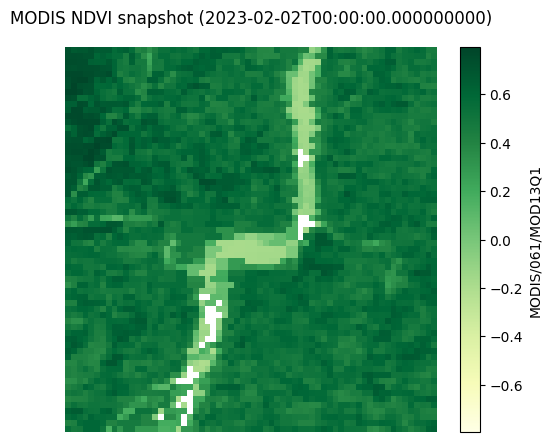

In [56]:
# visualize one time step
time_index = 2
# Select band and plot
if "band" in da_asia_cubo.dims:
    ndvi = da_asia_cubo.sel(band="NDVI")
else:
    ndvi = da_asia_cubo
ndvi_2d = ndvi.isel(time=time_index).squeeze() / 10000.0
plt.figure(figsize=(6, 5))
ndvi_2d.plot(cmap="YlGn")
plt.title(f"MODIS NDVI snapshot ({ndvi.time.values[time_index]})")
plt.axis("off")
plt.show()

### Optional Sentinel-3 variant in GEE-backed cubo

In [57]:

# Sentinel-3 OLCI in GEE
da_s3_cubo = cubo.create(
    lat=22.5,
    lon=90.0,
    collection="COPERNICUS/S3/OLCI",
    bands=["Oa08_radiance", "Oa06_radiance", "Oa04_radiance"],
    start_date="2023-01-01",
    end_date="2023-01-31",
    edge_size=64,
    resolution=300,
    gee=True,
)
da_s3_cubo

<xarray.DataArray 'COPERNICUS/S3/OLCI' (time: 36, band: 3, y: 64, x: 64)> Size: 2MB
dask.array<transpose, shape=(36, 3, 64, 64), dtype=float32, chunksize=(36, 1, 64, 64), chunktype=numpy.ndarray>
Coordinates:
  * time                       (time) datetime64[ns] 288B 2023-01-02T04:31:17...
  * band                       (band) object 24B 'Oa08_radiance' ... 'Oa04_ra...
  * y                          (y) float64 512B 2.482e+06 ... 2.501e+06
  * x                          (x) float64 512B 7.994e+05 ... 8.183e+05
    cubo:distance_from_center  (y, x) float64 33kB 1.332e+04 ... 1.341e+04
Attributes:
    collection:           COPERNICUS/S3/OLCI
    stac:                 https://earthengine-stac.storage.googleapis.com/cat...
    epsg:                 32645
    resolution:           300
    edge_size:            64
    edge_size_m:          19200
    central_lat:          22.5
    central_lon:          90.0
    central_y:            2491265.989701727
    central_x:            808665.6894232032
    time_coverage_start:  2023-01-01
    time_coverage_end:    2023-01-31

# Part 3 — Earth Engine + Xee for xarray-native analysis

`xee` is excellent when you want Earth Engine collections to feel more like xarray datasets.
This is a strong teaching path for people already comfortable with Python arrays.

## Example 3A: Africa MODIS NDVI time series with Xee

In [ ]:

# Earth Engine geometry
africa_roi = ee.Geometry.Rectangle(africa_bbox)

# MODIS NDVI collection
modis_ic = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterBounds(africa_roi)
    .filterDate("2023-01-01", "2023-12-31")
    .select(["NDVI", "EVI"])
)

# Open with xee
# ds_modis_xee = xr.open_dataset(
#     modis_ic,
#     engine="ee",
#     geometry=africa_bbox,
#     scale=250,
# )
# ds_modis_xee

## Example 3B: Reduce to a simple regional mean time series

In [ ]:

# Example post-processing once ds_modis_xee is loaded:
#
# ndvi = ds_modis_xee["NDVI"] / 10000.0  # MODIS NDVI is typically scaled
# ndvi_mean = ndvi.mean(dim=("X", "Y")).to_series()
#
# ax = ndvi_mean.plot(figsize=(10, 4), marker="o")
# ax.set_title("Lake Victoria region — MODIS NDVI mean (2023)")
# ax.set_ylabel("NDVI")
# plt.show()

## Example 3C: Simple anomaly against a baseline

In [ ]:

# Illustrative anomaly workflow
#
# modis_baseline_ic = (
#     ee.ImageCollection("MODIS/061/MOD13Q1")
#     .filterBounds(africa_roi)
#     .filterDate("2015-01-01", "2022-12-31")
#     .select("NDVI")
# )
#
# ds_baseline = xr.open_dataset(
#     modis_baseline_ic,
#     engine="ee",
#     geometry=africa_bbox,
#     scale=250,
# )
#
# baseline_mean = (ds_baseline["NDVI"] / 10000.0).mean(dim="time")
# current_mean  = (ds_modis_xee["NDVI"] / 10000.0).mean(dim="time")
# anomaly = current_mean - baseline_mean
#
# anomaly.plot(figsize=(6, 5), cmap="RdYlGn")
# plt.title("NDVI anomaly: 2023 vs 2015-2022 baseline")
# plt.show()

# Part 4 — Asia example: Sentinel-3 OLCI with MPC + cubo (no GEE required)

Sentinel-3 OLCI is useful for:
- coastal water color context,
- sediment/turbidity proxies,
- large estuaries and deltas,
- broad land-water transitions.

For participants without GEE access, use `cubo` directly with MPC/STAC-backed collections.

In [ ]:
# MPC + cubo Sentinel-3 example (Asia AOI)

lat_asia = 22.0
lon_asia = 89.0

# Build a small cube around a point in the Asia AOI using MPC/STAC-backed data
# Keep this small in live demos for faster response.
# da_s3_mpc = cubo.create(
#     lat=lat_asia,
#     lon=lon_asia,
#     collection="sentinel-3-olci-lfr-l2-netcdf",
#     bands=["Oa08_radiance", "Oa06_radiance", "Oa04_radiance"],
#     start_date="2023-01-01",
#     end_date="2023-01-31",
#     edge_size=96,
#     resolution=300,
# )
# da_s3_mpc

## Quicklook visualization idea

In [ ]:
# Quicklook idea once da_s3_mpc is loaded
#

# Example structure may vary by backend; adapt dims/coords if needed:
# rgb = xr.concat(
#     [
#         da_s3_mpc.sel(band="Oa08_radiance").isel(time=0),
#         da_s3_mpc.sel(band="Oa06_radiance").isel(time=0),
#         da_s3_mpc.sel(band="Oa04_radiance").isel(time=0),
#     ],
#     dim="band"
# )
#

# rgb = rgb / rgb.quantile(0.98)
# rgb = rgb.clip(0, 1)
#

# plt.figure(figsize=(6, 6))
# plt.imshow(np.transpose(rgb.values, (1, 2, 0)))
# plt.title("Sentinel-3 OLCI quicklook — MPC + cubo")
# plt.axis("off")
# plt.show()

# Part 5 — Integrated approach with MPC + cubo (no GEE required)

A resilience workflow is usually stronger when satellite observations are interpreted together with:
- rainfall,
- temperature,
- hydrology,
- exposure and vulnerability layers.

Below is an MPC + cubo pattern for rainfall and vegetation context.

## Example 5A: CHIRPS rainfall + MODIS NDVI in Africa

In [ ]:
# Find rainfall collections in MPC catalog (optional helper)
print("Possible rainfall collections in MPC catalog:")
for collection in catalog.get_collections():
    cid = collection.id.lower()
    if "chirps" in cid or "precip" in cid or "rain" in cid:
        print("-", collection.id)

# MPC + cubo example setup (Africa AOI)
lat_africa = 5.84
lon_africa = 43.67

# MODIS NDVI cube via MPC
# da_modis_mpc = cubo.create(
#     lat=lat_africa,
#     lon=lon_africa,
#     collection="modis-13Q1-061",
#     bands=["250m_16_days_NDVI"],
#     start_date="2023-01-01",
#     end_date="2023-12-31",
#     edge_size=96,
#     resolution=250,
# )
#

# CHIRPS rainfall cube via MPC (collection ID may vary by deployment)
# da_chirps_mpc = cubo.create(
#     lat=lat_africa,
#     lon=lon_africa,
#     collection="chirps-2.0",
#     bands=["precip"],
#     start_date="2023-01-01",
#     end_date="2023-12-31",
#     edge_size=96,
#     resolution=5566,
# )

In [ ]:
# Example combined plot once da_modis_mpc and da_chirps_mpc are available
#

# ndvi = da_modis_mpc.sel(band="250m_16_days_NDVI") / 10000.0
# ndvi_series = ndvi.mean(dim=("y", "x")).to_series()
#

# rain = da_chirps_mpc.sel(band="precip")
# rain_series = rain.mean(dim=("y", "x")).to_series()
#

# fig, ax1 = plt.subplots(figsize=(11, 4))
# rain_series.plot(ax=ax1, kind="bar", alpha=0.6)
# ax1.set_ylabel("Rainfall")
# ax1.set_title("Africa example — MPC + cubo rainfall and vegetation context")
#

# ax2 = ax1.twinx()
# ndvi_series.plot(ax=ax2, color="darkgreen", marker="o")
# ax2.set_ylabel("NDVI")
# plt.show()

# Comparison of the four main access patterns

| Option | Best use | Strength | Watch out for |
|---|---|---|---|
| STAC API | discovery and interoperable search | standards-based, portable | actual asset handling may still require extra code |
| MPC | cloud-hosted STAC datasets | easy search and many public datasets | collection naming and asset structure vary |
| GEE | large-scale catalog + processing | huge catalog, server-side filtering | authentication and API concepts |
| Xee | Earth Engine to xarray | analysis-friendly for Python users | some workflows still need EE thinking |
| cubo | compact data-cube creation | simple mental model across STAC/GEE | backend support varies by collection |

## Key message

Climate resilience monitoring is rarely about one sensor or one platform. The most practical skill is learning to move between:
- discovery,
- access,
- cube creation,
- aggregation,
- interpretation.

### Interpretation examples

- Lower NDVI together with rainfall deficits can indicate drought stress.
- Sentinel-3 coastal color patterns can help identify sediment plumes and broad coastal change context.
- Medium-resolution products are excellent for regional monitoring, but not for parcel-scale decisions.

# Exercises for participants

1. Replace the Africa bounding box with a Sahel AOI or AOI of your choice.
2. Replace the Asia AOI with the Mekong Delta.
3. Add a 2019–2024 annual NDVI summary.
4. Compute a monthly climatology.
5. Add MODIS LST or CHIRPS rainfall and compare seasonal patterns.
6. Try the same workflow through:
   - raw STAC search,
   - Xee,
   - cubo.

# Closing remarks

This notebook intentionally mixes several access patterns because that reflects real EO practice:
- no single interface solves every workflow,
- standards like STAC improve portability,
- Earth Engine accelerates computation,
- xarray-based tools make Python analysis cleaner,
- `cubo` can reduce boilerplate for prototyping.